In [155]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt


In [189]:
data = fetch_california_housing()

data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [ ]:
X = data.data[:, np.newaxis, 0]  
y = data.target  

X = (X - np.mean(X)) / np.std(X)


X = np.hstack((np.ones((X.shape[0], 1)), X))



In [159]:
weights = np.random.rand(2)  

learning_rate = 0.01
epochs = 100

In [161]:
def sigmoid(z):
    
    return 1 / (1 + np.exp(-z))

In [185]:
mse_list = []
for epoch in range(epochs):
    
    z = np.dot(X, weights)
    y_pred = sigmoid(z)
    
    
    error = y_pred - y
    gradient = np.dot(X.T, error) / len(y)
    
    
    weights -= learning_rate * gradient
    
    
    mse = np.mean((y - y_pred) ** 2)
    mse_list.append(mse)



print(f"Final weights: {weights}")

y_pred_final = sigmoid(np.dot(X, weights))

mse_final = np.mean((y - y_pred_final) ** 2)

# R sq..
ss_total = np.sum((y - np.mean(y)) ** 2)
ss_residual = np.sum((y - y_pred_final) ** 2)
r2_score = (1 - (ss_residual / ss_total))**2

print(f"Final MSE: {mse_final}")
print(f"R^2 Score: {r2_score}")


Final weights: [7.82969942 4.90497046]
Final MSE: 2.4871492906162613
R^2 Score: 0.7531806499436068


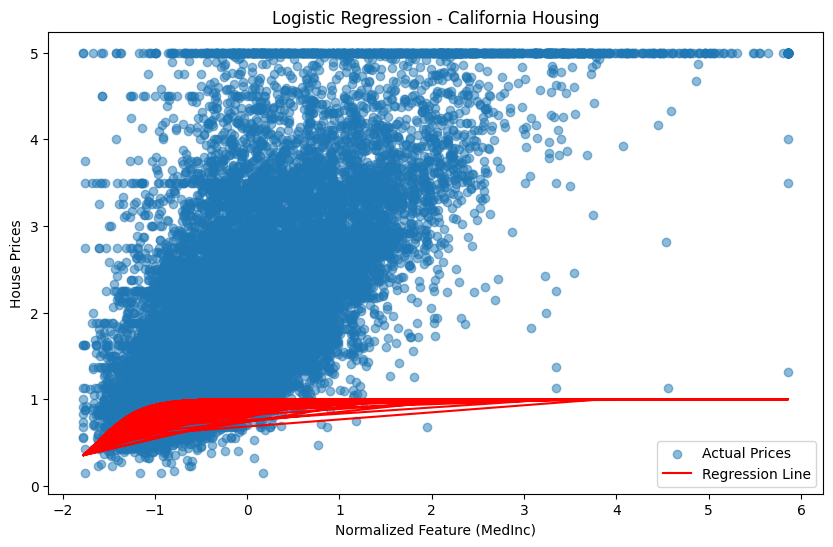

In [183]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 1], y, label="Actual Prices", alpha=0.5)
plt.plot(X[:, 1], y_pred_final, color="red", label="Regression Line")
plt.xlabel("Normalized Feature (MedInc)")
plt.ylabel("House Prices")
plt.title("Logistic Regression - California Housing")
plt.legend()
plt.show()
